# Computer Vision Practical Notebook

This notebook demonstrates all the concepts from the Computer Vision Introduction notes with real images and working code.

## Table of Contents
1. [Setup and Imports](#1-setup)
2. [Images as Mathematical Objects](#2-images)
3. [Convolution Operations](#3-convolution)
4. [Classical Computer Vision](#4-classical)
5. [CNN Architectures](#5-cnn)
6. [Object Detection](#6-detection)
7. [Semantic Segmentation](#7-segmentation)
8. [Vision Transformers](#8-vit)
9. [CLIP Zero-Shot Classification](#9-clip)
10. [Diffusion Models](#10-diffusion)
11. [Edge Deployment](#11-edge)

## 1. Setup and Imports <a name="1-setup"></a>

In [ ]:
# Install required packages (uncomment if needed)
# !pip install torch torchvision matplotlib numpy opencv-python pillow
# !pip install transformers timm  # For pretrained models
# !pip install scikit-image scipy

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import cv2
import requests
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Helper function to load images from URL
def load_image_from_url(url, size=None):
    """Load an image from URL and optionally resize it."""
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    }
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()  # Raise an error for bad status codes
    
    # Create BytesIO object and seek to beginning
    img_bytes = BytesIO(response.content)
    img_bytes.seek(0)  # Ensure we're at the beginning
    
    # Check if we got actual image data
    if len(response.content) < 100:
        raise ValueError(f"Response too small ({len(response.content)} bytes), likely not an image")
    
    # Check content type
    content_type = response.headers.get('Content-Type', '')
    if content_type and 'image' not in content_type.lower() and 'octet-stream' not in content_type.lower():
        raise ValueError(f"Unexpected content type: {content_type}")
    
    img = Image.open(img_bytes).convert('RGB')
    if size:
        img = img.resize(size)
    return img

# Helper function to display images
def show_images(images, titles=None, figsize=(15, 5), cmap=None):
    """Display multiple images in a row."""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for i, (img, ax) in enumerate(zip(images, axes)):
        if isinstance(img, torch.Tensor):
            img = img.cpu().numpy()
            if img.ndim == 3 and img.shape[0] in [1, 3]:
                img = np.transpose(img, (1, 2, 0))
            if img.shape[-1] == 1:
                img = img.squeeze()
        ax.imshow(img, cmap=cmap if img.ndim == 2 else None)
        if titles:
            ax.set_title(titles[i])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Using device: cpu


Successfully loaded image from: https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=400
Image size: (224, 224)


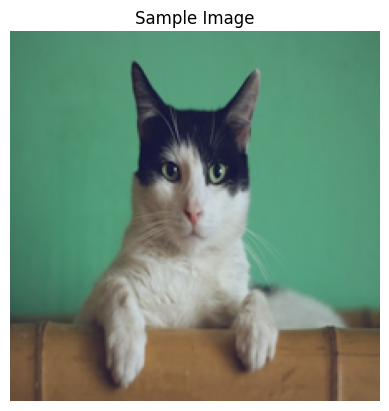

In [11]:
# Load a sample image for demonstrations
# Using reliable image sources
sample_urls = [
    "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=400",  # Cat on Unsplash
    "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg",  # PyTorch sample dog
    "https://picsum.photos/400/400",  # Lorem Picsum random image
]

sample_image = None
for url in sample_urls:
    try:
        sample_image = load_image_from_url(url, size=(224, 224))
        print(f"Successfully loaded image from: {url}")
        break
    except Exception as e:
        print(f"Failed to load from {url}: {e}")

if sample_image is None:
    # Ultimate fallback: create a synthetic image
    print("Creating synthetic test image...")
    # Create a more interesting synthetic image with gradients and shapes
    synthetic = np.zeros((224, 224, 3), dtype=np.uint8)
    # Add gradient background
    for i in range(224):
        synthetic[i, :, 0] = int(255 * i / 224)  # Red gradient
        synthetic[:, i, 2] = int(255 * i / 224)  # Blue gradient
    # Add a circle
    cv2.circle(synthetic, (112, 112), 50, (0, 255, 0), -1)
    sample_image = Image.fromarray(synthetic)

print(f"Image size: {sample_image.size}")
plt.imshow(sample_image)
plt.title("Sample Image")
plt.axis('off')
plt.show()

## 2. Images as Mathematical Objects <a name="2-images"></a>

Understanding how images are represented as tensors.

Image shape: (224, 224, 3)
Data type: uint8
Min value: 10, Max value: 221


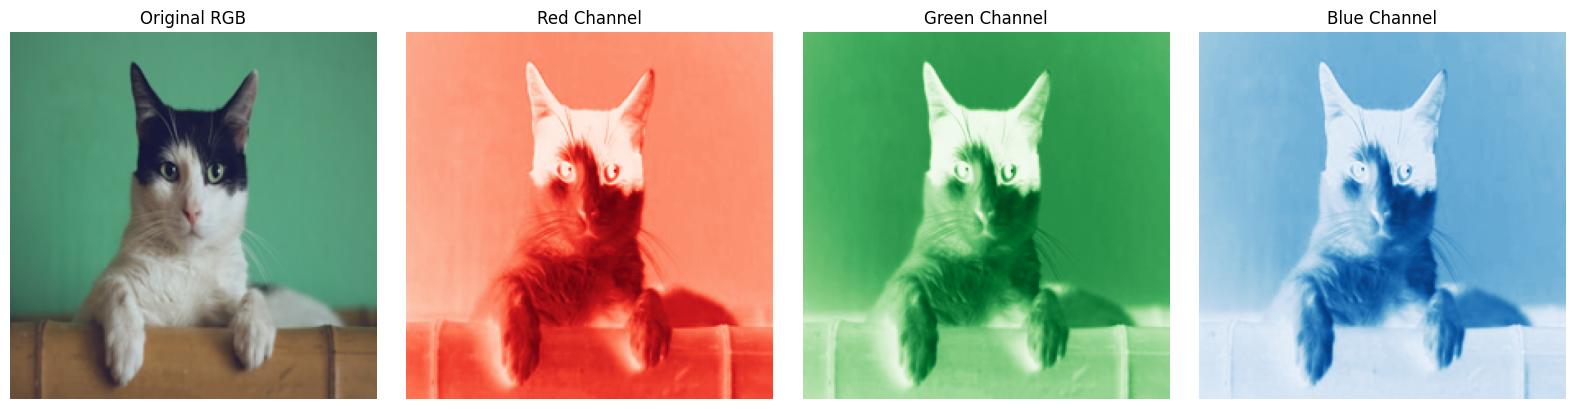

In [12]:
# Convert image to numpy array
img_array = np.array(sample_image)
print(f"Image shape: {img_array.shape}")
print(f"Data type: {img_array.dtype}")
print(f"Min value: {img_array.min()}, Max value: {img_array.max()}")

# Show individual channels
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_array)
axes[0].set_title('Original RGB')

axes[1].imshow(img_array[:, :, 0], cmap='Reds')
axes[1].set_title('Red Channel')

axes[2].imshow(img_array[:, :, 1], cmap='Greens')
axes[2].set_title('Green Channel')

axes[3].imshow(img_array[:, :, 2], cmap='Blues')
axes[3].set_title('Blue Channel')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

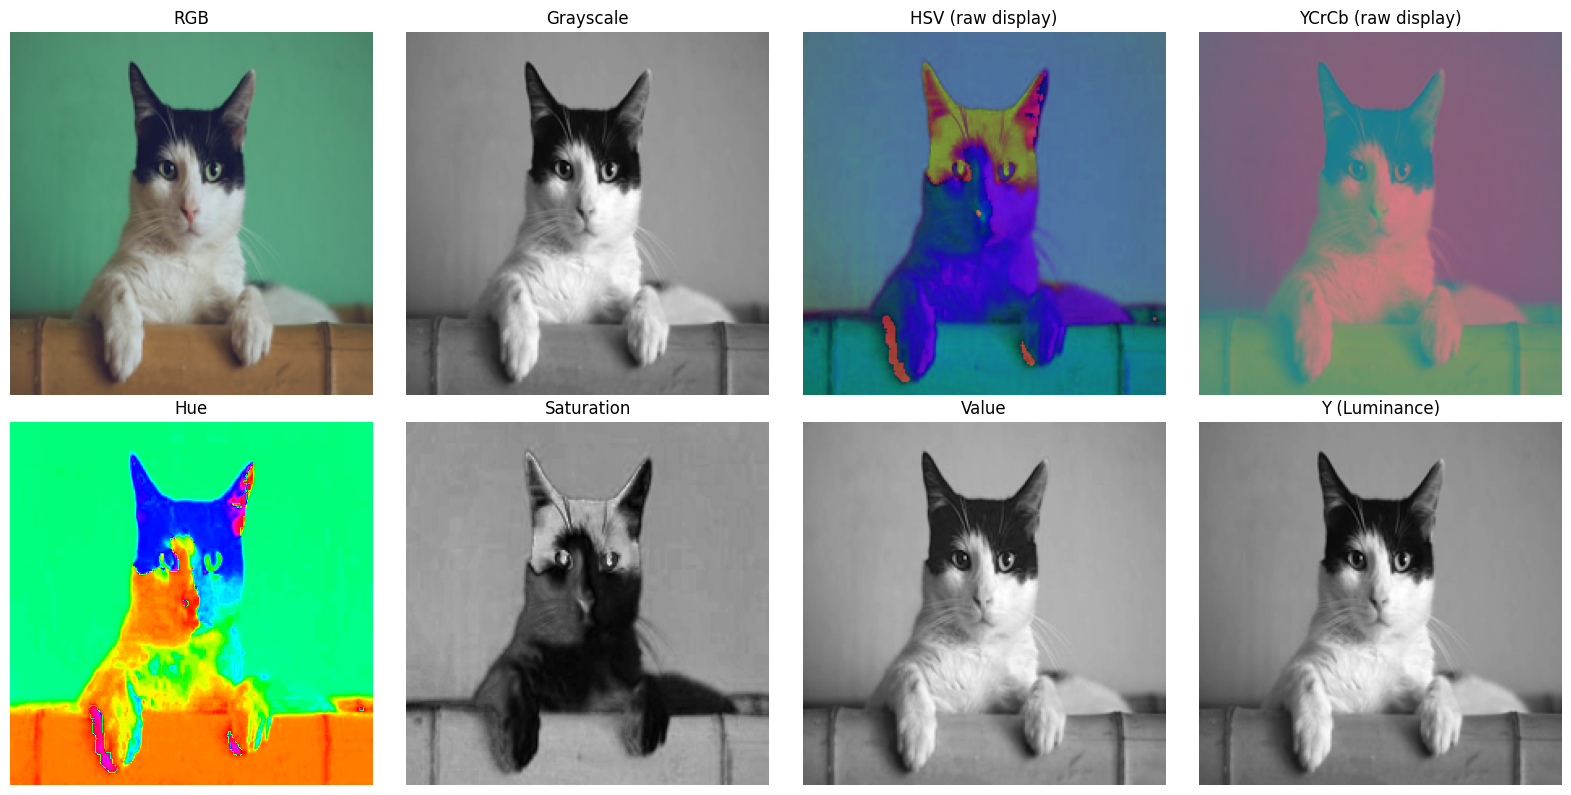

In [13]:
# Color Space Conversions
img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
img_hsv = cv2.cvtColor(img_array, cv2.COLOR_RGB2HSV)
img_gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
img_ycrcb = cv2.cvtColor(img_array, cv2.COLOR_RGB2YCrCb)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# First row: color spaces
axes[0, 0].imshow(img_array)
axes[0, 0].set_title('RGB')

axes[0, 1].imshow(img_gray, cmap='gray')
axes[0, 1].set_title('Grayscale')

axes[0, 2].imshow(img_hsv)
axes[0, 2].set_title('HSV (raw display)')

axes[0, 3].imshow(img_ycrcb)
axes[0, 3].set_title('YCrCb (raw display)')

# Second row: HSV channels
axes[1, 0].imshow(img_hsv[:, :, 0], cmap='hsv')
axes[1, 0].set_title('Hue')

axes[1, 1].imshow(img_hsv[:, :, 1], cmap='gray')
axes[1, 1].set_title('Saturation')

axes[1, 2].imshow(img_hsv[:, :, 2], cmap='gray')
axes[1, 2].set_title('Value')

axes[1, 3].imshow(img_ycrcb[:, :, 0], cmap='gray')
axes[1, 3].set_title('Y (Luminance)')

for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [14]:
# ImageNet Normalization
# Standard normalization used for pretrained models

imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

# Normalize the image
img_normalized = img_array / 255.0  # Scale to [0, 1]
img_imagenet_norm = (img_normalized - imagenet_mean) / imagenet_std

print(f"Original range: [{img_array.min()}, {img_array.max()}]")
print(f"After /255: [{img_normalized.min():.3f}, {img_normalized.max():.3f}]")
print(f"After ImageNet norm: [{img_imagenet_norm.min():.3f}, {img_imagenet_norm.max():.3f}]")
print(f"\nImageNet mean: {imagenet_mean}")
print(f"ImageNet std: {imagenet_std}")

Original range: [10, 221]
After /255: [0.039, 0.867]
After ImageNet norm: [-1.947, 2.047]

ImageNet mean: [0.485 0.456 0.406]
ImageNet std: [0.229 0.224 0.225]


## 3. Convolution Operations <a name="3-convolution"></a>

Understanding convolution with different kernels.

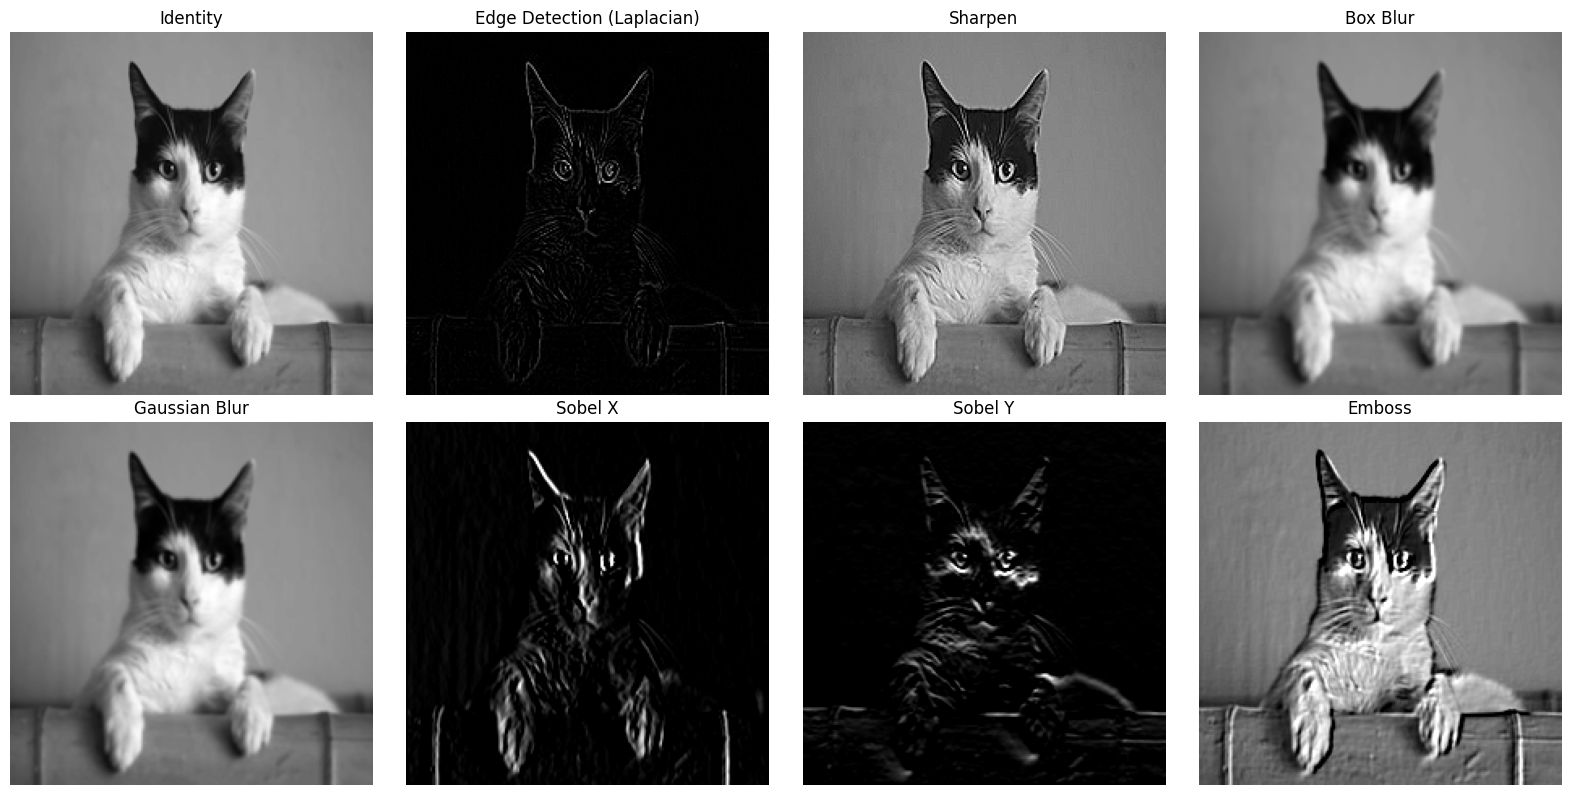

In [15]:
# Define common kernels
kernels = {
    'Identity': np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]], dtype=np.float32),
    'Edge Detection (Laplacian)': np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32),
    'Sharpen': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32),
    'Box Blur': np.ones((3, 3), dtype=np.float32) / 9,
    'Gaussian Blur': np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float32) / 16,
    'Sobel X': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32),
    'Sobel Y': np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32),
    'Emboss': np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]], dtype=np.float32),
}

# Apply kernels to grayscale image
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (name, kernel) in zip(axes.flat, kernels.items()):
    # Apply convolution using OpenCV
    result = cv2.filter2D(img_gray, -1, kernel)
    ax.imshow(result, cmap='gray')
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [16]:
# Manual convolution example with numeric values
def manual_convolution_demo():
    """Demonstrate convolution step by step."""
    # Small image patch
    patch = np.array([
        [10, 20, 30, 20, 10],
        [20, 30, 40, 30, 20],
        [30, 40, 50, 40, 30],
        [20, 30, 40, 30, 20],
        [10, 20, 30, 20, 10]
    ], dtype=np.float32)
    
    # Sobel X kernel (vertical edge detector)
    kernel = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float32)
    
    print("Input patch (5x5):")
    print(patch)
    print("\nKernel (Sobel X):")
    print(kernel)
    
    # Manual calculation for position (1,1)
    neighborhood = patch[0:3, 0:3]
    print(f"\nNeighborhood at (1,1):")
    print(neighborhood)
    
    result = np.sum(neighborhood * kernel)
    print(f"\nConvolution result at (1,1): {result}")
    print("Calculation:")
    print(f"  (-1×10) + (0×20) + (1×30) = {-1*10 + 0*20 + 1*30}")
    print(f"  (-2×20) + (0×30) + (2×40) = {-2*20 + 0*30 + 2*40}")
    print(f"  (-1×30) + (0×40) + (1×50) = {-1*30 + 0*40 + 1*50}")
    print(f"  Sum = {-10 + 30 - 40 + 80 - 30 + 50}")
    
    # Full convolution
    full_result = cv2.filter2D(patch, -1, kernel, borderType=cv2.BORDER_CONSTANT)
    print(f"\nFull convolution output (5x5 with zero padding):")
    print(full_result.astype(int))

manual_convolution_demo()

Input patch (5x5):
[[10. 20. 30. 20. 10.]
 [20. 30. 40. 30. 20.]
 [30. 40. 50. 40. 30.]
 [20. 30. 40. 30. 20.]
 [10. 20. 30. 20. 10.]]

Kernel (Sobel X):
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]

Neighborhood at (1,1):
[[10. 20. 30.]
 [20. 30. 40.]
 [30. 40. 50.]]

Convolution result at (1,1): 80.0
Calculation:
  (-1×10) + (0×20) + (1×30) = 20
  (-2×20) + (0×30) + (2×40) = 40
  (-1×30) + (0×40) + (1×50) = 20
  Sum = 80

Full convolution output (5x5 with zero padding):
[[  70   60    0  -60  -70]
 [ 120   80    0  -80 -120]
 [ 140   80    0  -80 -140]
 [ 120   80    0  -80 -120]
 [  70   60    0  -60  -70]]


In [17]:
# Demonstrate padding, stride, and dilation
def demonstrate_conv_params():
    """Show effects of padding, stride, and dilation."""
    # Create a simple input
    input_tensor = torch.randn(1, 1, 8, 8)
    
    # Different convolution configurations
    configs = [
        ('No padding, stride=1', nn.Conv2d(1, 1, 3, stride=1, padding=0)),
        ('Padding=1, stride=1', nn.Conv2d(1, 1, 3, stride=1, padding=1)),
        ('Padding=1, stride=2', nn.Conv2d(1, 1, 3, stride=2, padding=1)),
        ('Dilation=2', nn.Conv2d(1, 1, 3, stride=1, padding=2, dilation=2)),
    ]
    
    print(f"Input shape: {input_tensor.shape}")
    print("\nOutput shapes for different configurations:")
    
    for name, conv in configs:
        output = conv(input_tensor)
        print(f"  {name}: {output.shape}")
        
demonstrate_conv_params()

Input shape: torch.Size([1, 1, 8, 8])

Output shapes for different configurations:
  No padding, stride=1: torch.Size([1, 1, 6, 6])
  Padding=1, stride=1: torch.Size([1, 1, 8, 8])
  Padding=1, stride=2: torch.Size([1, 1, 4, 4])
  Dilation=2: torch.Size([1, 1, 8, 8])


## 4. Classical Computer Vision <a name="4-classical"></a>

Edge detection, corner detection, and feature descriptors.

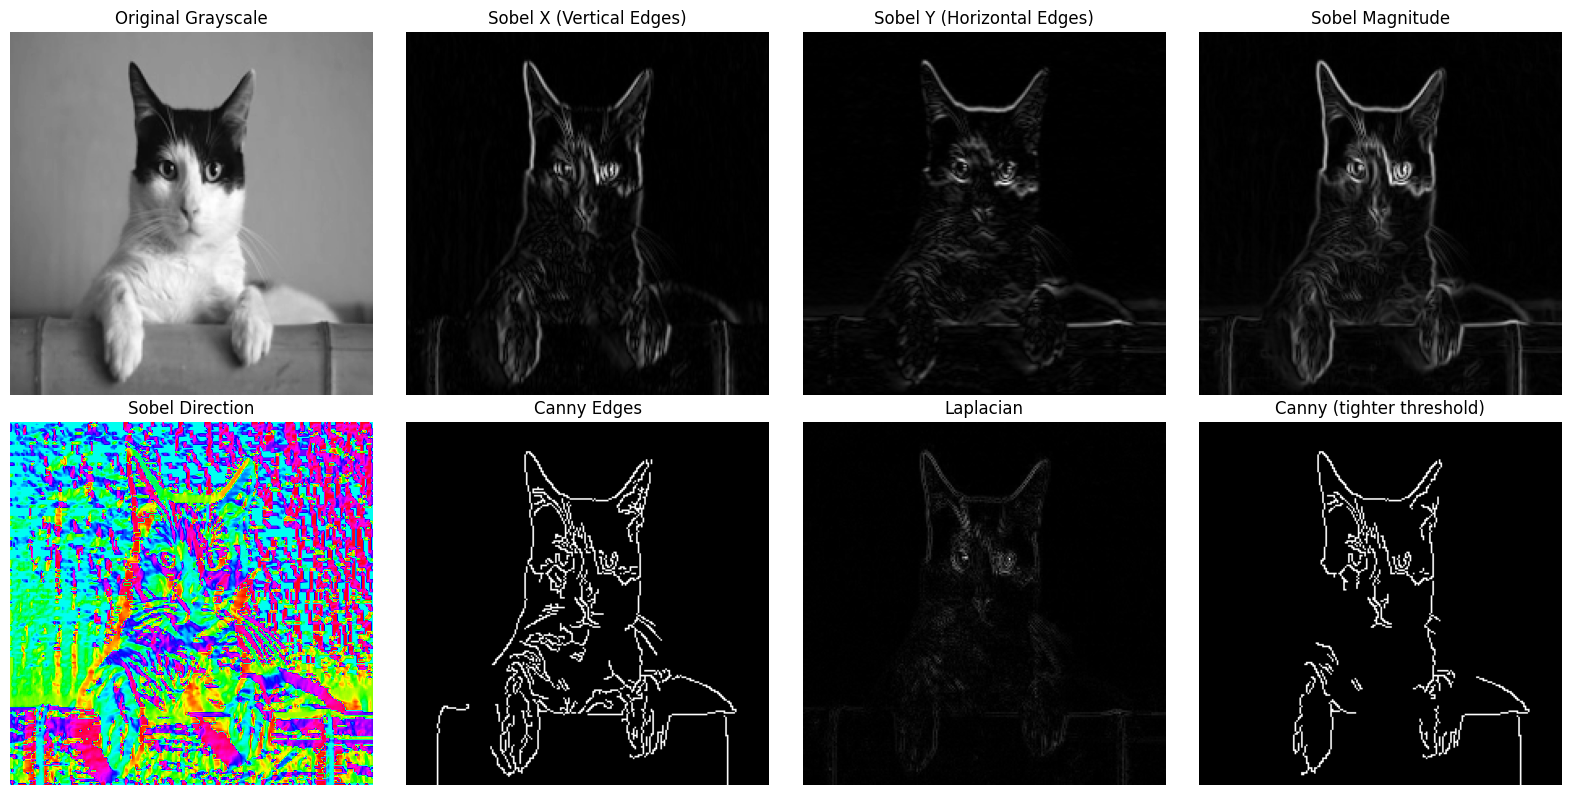

In [18]:
# Edge Detection Comparison
def edge_detection_demo(image):
    """Compare different edge detection methods."""
    gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
    
    # Sobel edges
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel_dir = np.arctan2(sobel_y, sobel_x)
    
    # Canny edges
    canny = cv2.Canny(gray, 50, 150)
    
    # Laplacian
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    axes[0, 0].imshow(gray, cmap='gray')
    axes[0, 0].set_title('Original Grayscale')
    
    axes[0, 1].imshow(np.abs(sobel_x), cmap='gray')
    axes[0, 1].set_title('Sobel X (Vertical Edges)')
    
    axes[0, 2].imshow(np.abs(sobel_y), cmap='gray')
    axes[0, 2].set_title('Sobel Y (Horizontal Edges)')
    
    axes[0, 3].imshow(sobel_mag, cmap='gray')
    axes[0, 3].set_title('Sobel Magnitude')
    
    axes[1, 0].imshow(sobel_dir, cmap='hsv')
    axes[1, 0].set_title('Sobel Direction')
    
    axes[1, 1].imshow(canny, cmap='gray')
    axes[1, 1].set_title('Canny Edges')
    
    axes[1, 2].imshow(np.abs(laplacian), cmap='gray')
    axes[1, 2].set_title('Laplacian')
    
    # Canny with different thresholds
    canny_tight = cv2.Canny(gray, 100, 200)
    axes[1, 3].imshow(canny_tight, cmap='gray')
    axes[1, 3].set_title('Canny (tighter threshold)')
    
    for ax in axes.flat:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

edge_detection_demo(sample_image)

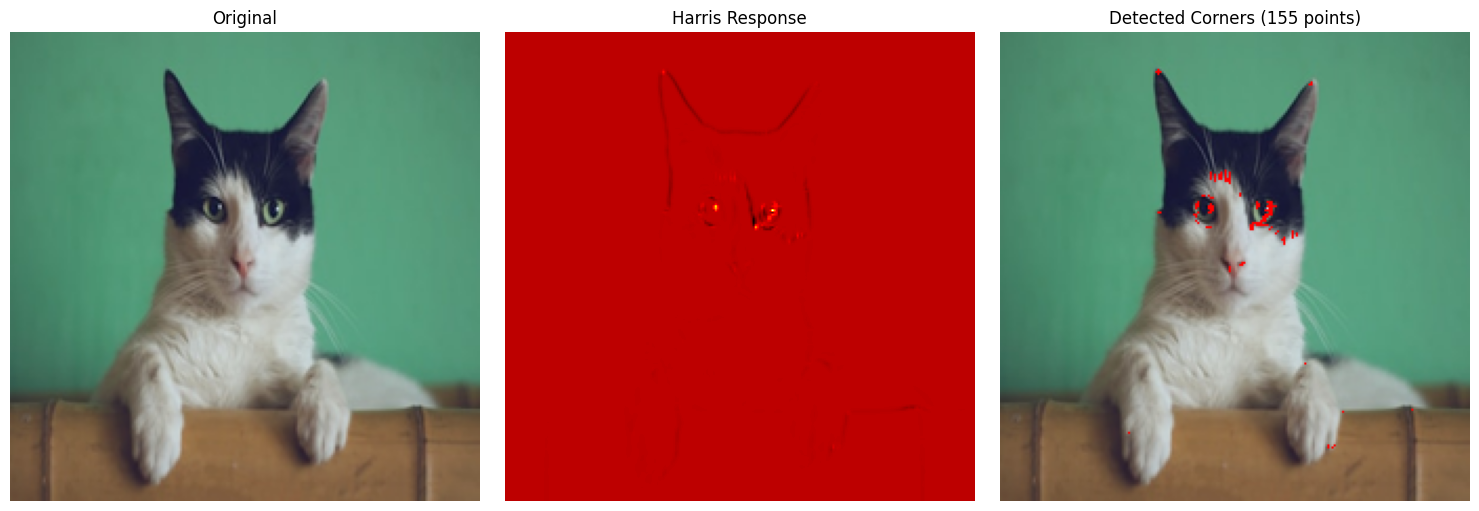

In [19]:
# Harris Corner Detection
def harris_corner_demo(image):
    """Demonstrate Harris corner detection."""
    img_array = np.array(image)
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY).astype(np.float32)
    
    # Harris corner detection
    harris = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)
    
    # Dilate to mark corners
    harris_dilated = cv2.dilate(harris, None)
    
    # Threshold to get corners
    threshold = 0.01 * harris.max()
    corner_mask = harris > threshold
    
    # Mark corners on image
    img_corners = img_array.copy()
    img_corners[corner_mask] = [255, 0, 0]  # Red
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_array)
    axes[0].set_title('Original')
    
    axes[1].imshow(harris, cmap='hot')
    axes[1].set_title('Harris Response')
    
    axes[2].imshow(img_corners)
    axes[2].set_title(f'Detected Corners ({corner_mask.sum()} points)')
    
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

harris_corner_demo(sample_image)

Number of keypoints: 117
Descriptor shape: (117, 128)
Each descriptor has 128 dimensions


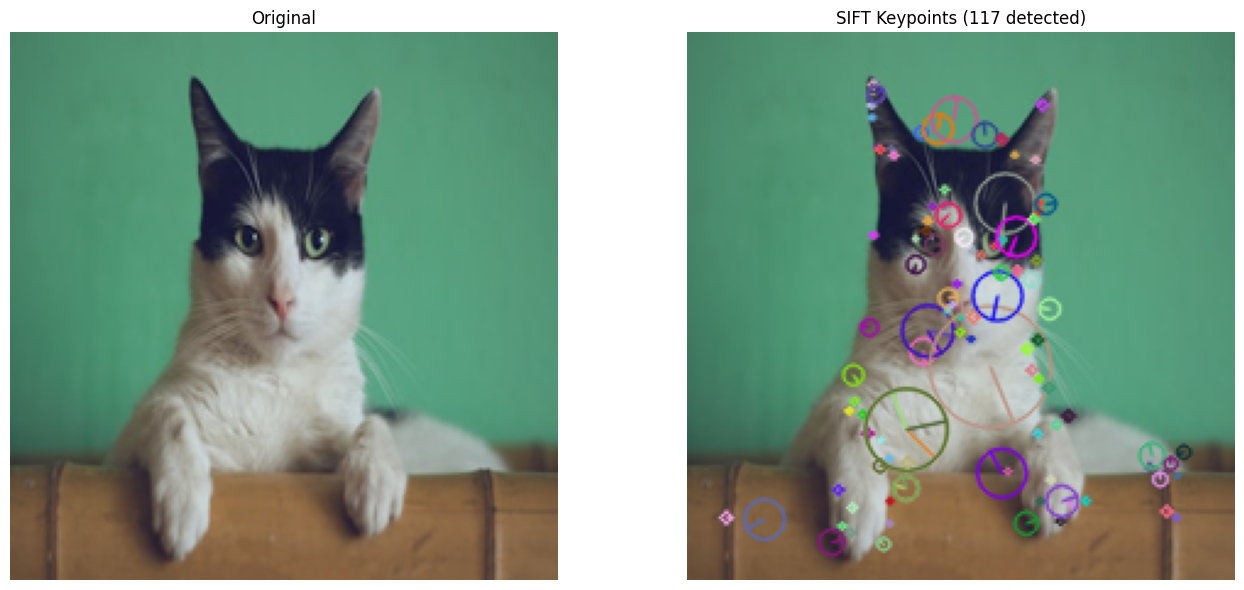


Sample keypoint properties:
  Position: (15.6, 198.0)
  Scale: 4.8
  Orientation: 8.5°
  Response: 0.0137


In [20]:
# SIFT Feature Detection and Matching
def sift_demo(image):
    """Demonstrate SIFT keypoints and descriptors."""
    img_array = np.array(image)
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    
    # Create SIFT detector
    sift = cv2.SIFT_create()
    
    # Detect keypoints and compute descriptors
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    
    print(f"Number of keypoints: {len(keypoints)}")
    print(f"Descriptor shape: {descriptors.shape}")
    print(f"Each descriptor has {descriptors.shape[1]} dimensions")
    
    # Draw keypoints
    img_keypoints = cv2.drawKeypoints(
        img_array, keypoints, None, 
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].imshow(img_array)
    axes[0].set_title('Original')
    
    axes[1].imshow(img_keypoints)
    axes[1].set_title(f'SIFT Keypoints ({len(keypoints)} detected)')
    
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Show sample descriptor
    print(f"\nSample keypoint properties:")
    kp = keypoints[0]
    print(f"  Position: ({kp.pt[0]:.1f}, {kp.pt[1]:.1f})")
    print(f"  Scale: {kp.size:.1f}")
    print(f"  Orientation: {kp.angle:.1f}°")
    print(f"  Response: {kp.response:.4f}")

sift_demo(sample_image)

## 5. CNN Architectures <a name="5-cnn"></a>

Loading and using pretrained CNN models for classification.

In [21]:
# Load ImageNet class labels
IMAGENET_LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
response = requests.get(IMAGENET_LABELS_URL)
imagenet_labels = response.text.strip().split('\n')
print(f"Loaded {len(imagenet_labels)} ImageNet classes")
print(f"Sample classes: {imagenet_labels[:5]}")

Loaded 1000 ImageNet classes
Sample classes: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


In [22]:
# Preprocessing for ImageNet models
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def classify_image(model, image, top_k=5):
    """Classify an image using a pretrained model."""
    model.eval()
    
    # Preprocess
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    
    # Forward pass
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)
    
    # Get top-k predictions
    top_probs, top_indices = torch.topk(probabilities, top_k)
    
    results = []
    for prob, idx in zip(top_probs[0], top_indices[0]):
        results.append((imagenet_labels[idx], prob.item()))
    
    return results

In [23]:
# Compare different architectures
architectures = {
    'ResNet-18': models.resnet18(weights='IMAGENET1K_V1'),
    'ResNet-50': models.resnet50(weights='IMAGENET1K_V1'),
    'VGG-16': models.vgg16(weights='IMAGENET1K_V1'),
    'MobileNetV2': models.mobilenet_v2(weights='IMAGENET1K_V1'),
    'EfficientNet-B0': models.efficientnet_b0(weights='IMAGENET1K_V1'),
}

print("Classifying sample image with different architectures:\n")

for name, model in architectures.items():
    model = model.to(device)
    results = classify_image(model, sample_image)
    
    # Count parameters
    params = sum(p.numel() for p in model.parameters())
    
    print(f"\n{name} ({params/1e6:.1f}M parameters):")
    for label, prob in results[:3]:
        print(f"  {label}: {prob*100:.1f}%")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/yenokhakobyan/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 30.7MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/yenokhakobyan/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:03<00:00, 32.5MB/s]


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /Users/yenokhakobyan/.cache/torch/hub/checkpoints/vgg16-397923af.pth


...

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /Users/yenokhakobyan/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 22.5MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/yenokhakobyan/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 22.3MB/s]


Classifying sample image with different architectures:


ResNet-18 (11.7M parameters):
  Egyptian cat: 47.6%
  tabby: 13.0%
  Siamese cat: 5.5%

ResNet-50 (25.6M parameters):
  Egyptian cat: 78.5%
  tabby: 5.8%
  Siamese cat: 3.2%

VGG-16 (138.4M parameters):
  Egyptian cat: 53.9%
  tabby: 7.5%
  lynx: 7.1%

MobileNetV2 (3.5M parameters):
  Egyptian cat: 50.4%
  carton: 6.5%
  tabby: 6.0%

EfficientNet-B0 (5.3M parameters):
  Egyptian cat: 28.1%
  Siamese cat: 15.6%
  tabby: 15.2%


In [24]:
# Visualize ResNet architecture
def count_layers_params(model):
    """Count layers and parameters in a model."""
    total_params = 0
    trainable_params = 0
    layer_count = 0
    
    for name, param in model.named_parameters():
        total_params += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            layer_count += 1
    
    return layer_count, total_params, trainable_params

print("Architecture Comparison:")
print("-" * 60)
print(f"{'Model':<20} {'Layers':<10} {'Parameters':<15} {'Size (MB)':<10}")
print("-" * 60)

for name, model in architectures.items():
    layers, params, _ = count_layers_params(model)
    size_mb = params * 4 / (1024 * 1024)  # 4 bytes per float32
    print(f"{name:<20} {layers:<10} {params:,}" + f" {size_mb:.1f}")

Architecture Comparison:
------------------------------------------------------------
Model                Layers     Parameters      Size (MB) 
------------------------------------------------------------
ResNet-18            21         11,689,512 44.6
ResNet-50            54         25,557,032 97.5
VGG-16               16         138,357,544 527.8
MobileNetV2          53         3,504,872 13.4
EfficientNet-B0      82         5,288,548 20.2


layer1: shape = torch.Size([1, 64, 56, 56])


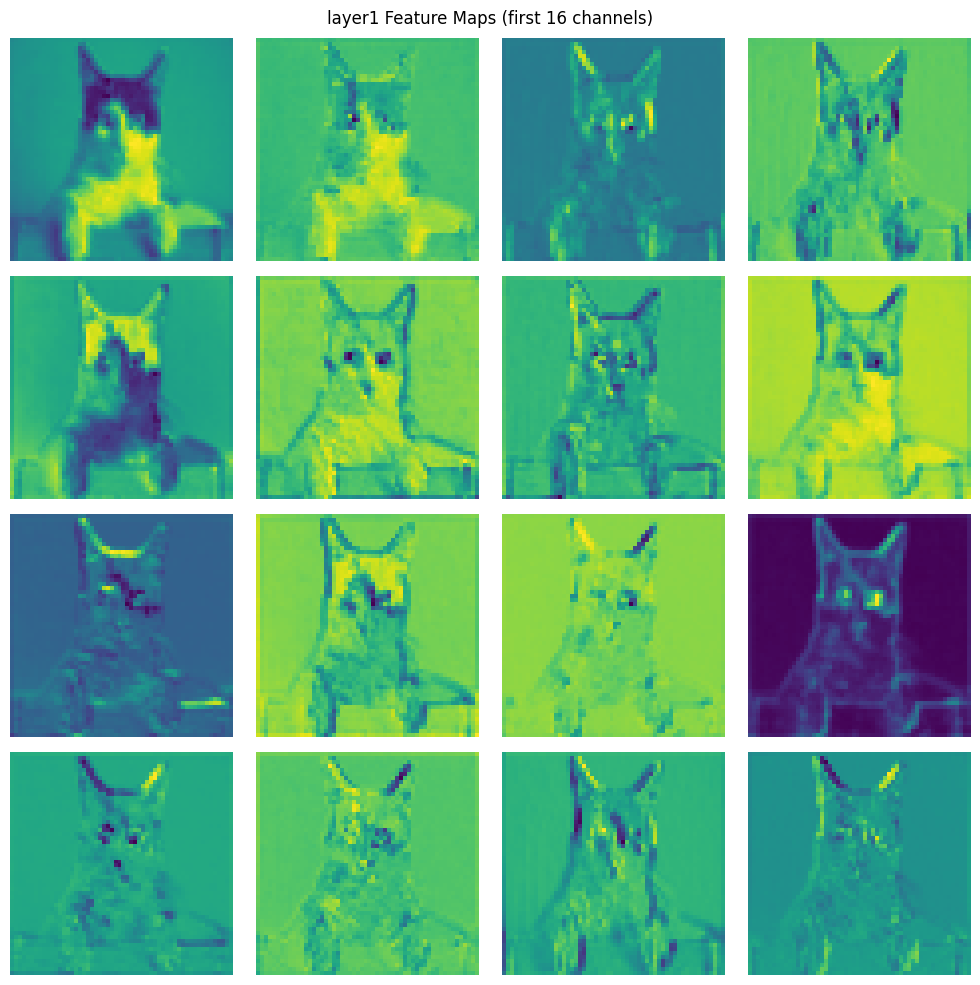

layer2: shape = torch.Size([1, 128, 56, 56])


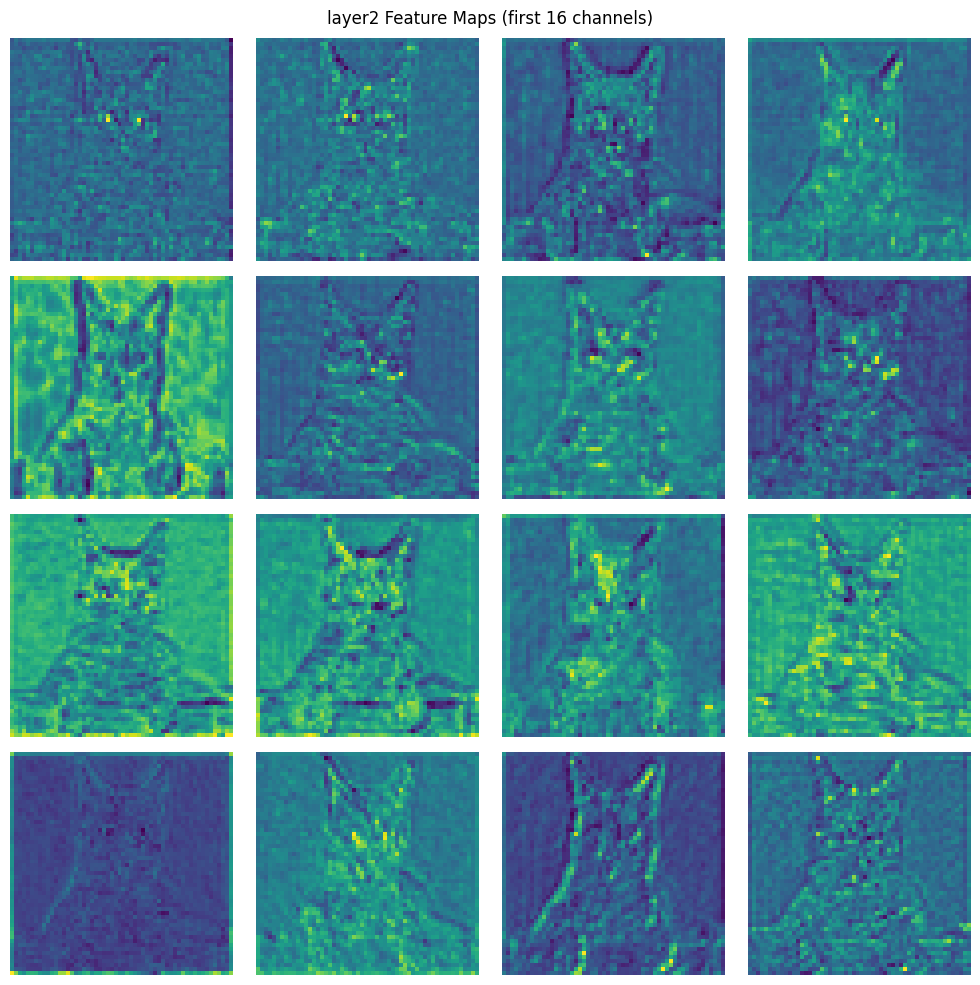

layer3: shape = torch.Size([1, 256, 28, 28])


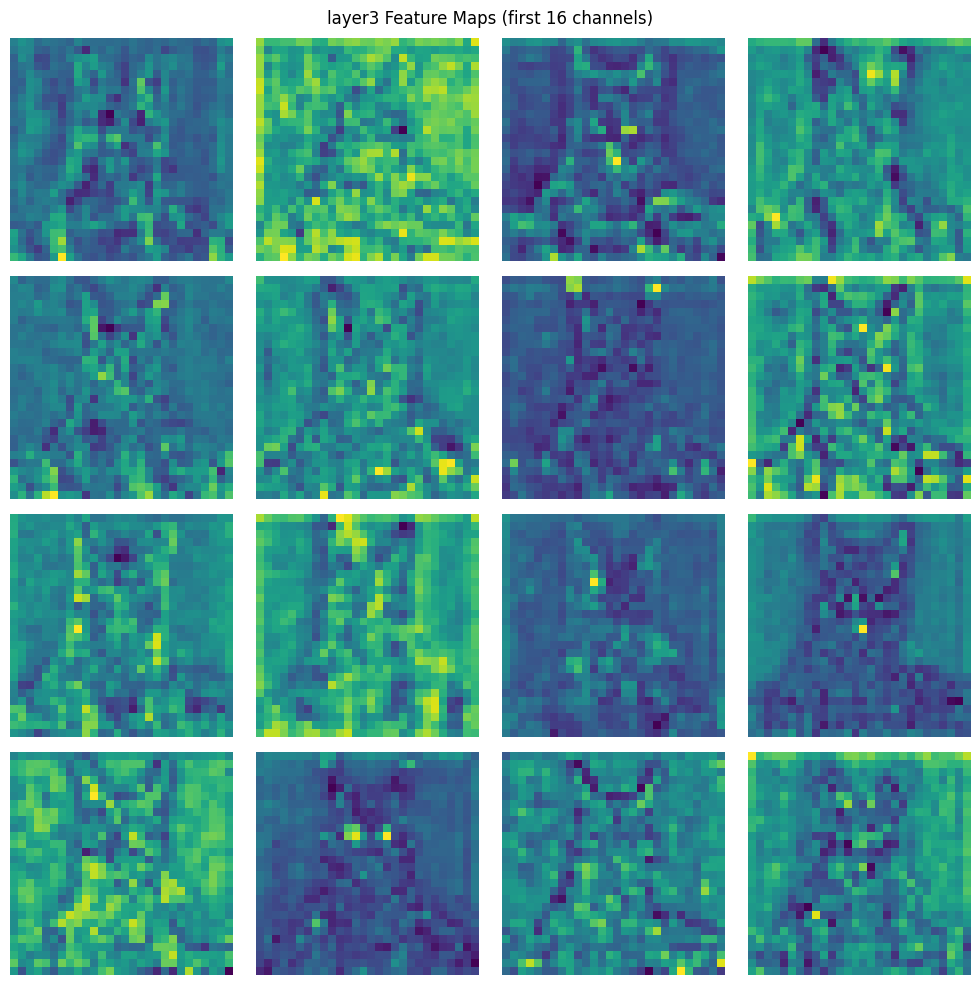

layer4: shape = torch.Size([1, 512, 14, 14])


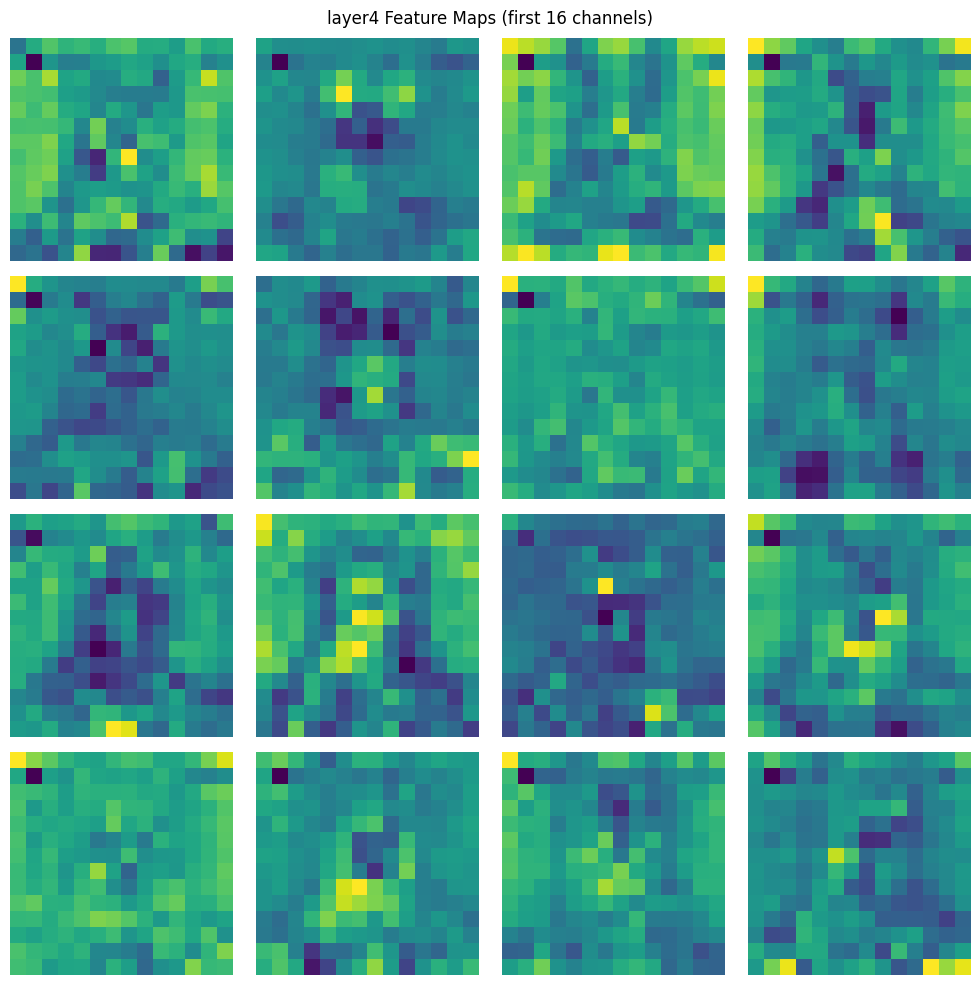

In [25]:
# Visualize feature maps from a CNN
def visualize_feature_maps(model, image, layer_name='layer1'):
    """Visualize intermediate feature maps."""
    model.eval()
    
    # Hook to capture feature maps
    feature_maps = {}
    
    def hook_fn(name):
        def hook(module, input, output):
            feature_maps[name] = output.detach()
        return hook
    
    # Register hooks
    hooks = []
    for name, module in model.named_modules():
        if layer_name in name:
            hooks.append(module.register_forward_hook(hook_fn(name)))
    
    # Forward pass
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        _ = model(input_tensor)
    
    # Remove hooks
    for hook in hooks:
        hook.remove()
    
    return feature_maps

# Visualize ResNet-50 features
resnet = models.resnet50(weights='IMAGENET1K_V1').to(device)

# Get features from different layers
for layer in ['layer1', 'layer2', 'layer3', 'layer4']:
    features = visualize_feature_maps(resnet, sample_image, layer)
    
    if features:
        key = list(features.keys())[0]
        feat = features[key]
        print(f"{layer}: shape = {feat.shape}")
        
        # Show first 16 channels
        fig, axes = plt.subplots(4, 4, figsize=(10, 10))
        for i, ax in enumerate(axes.flat):
            if i < feat.shape[1]:
                ax.imshow(feat[0, i].cpu().numpy(), cmap='viridis')
            ax.axis('off')
        plt.suptitle(f'{layer} Feature Maps (first 16 channels)')
        plt.tight_layout()
        plt.show()

## 6. Object Detection <a name="6-detection"></a>

Using pretrained object detection models.

In [26]:
# Load a pretrained Faster R-CNN model
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

# Load model with weights
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
detection_model = fasterrcnn_resnet50_fpn(weights=weights).to(device)
detection_model.eval()

# Get class labels
coco_labels = weights.meta["categories"]
print(f"COCO classes ({len(coco_labels)}): {coco_labels[:10]}...")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /Users/yenokhakobyan/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:05<00:00, 33.5MB/s] 

COCO classes (91): ['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat']...


In [27]:
# Load an image with multiple objects
detection_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Cat_November_2010-1a.jpg/1200px-Cat_November_2010-1a.jpg"
detection_image = load_image_from_url(detection_url)

# Preprocess for detection
detection_transform = transforms.Compose([
    transforms.ToTensor(),
])

def detect_objects(model, image, threshold=0.5):
    """Run object detection on an image."""
    model.eval()
    
    # Transform image
    img_tensor = detection_transform(image).unsqueeze(0).to(device)
    
    # Run detection
    with torch.no_grad():
        predictions = model(img_tensor)
    
    # Filter by threshold
    pred = predictions[0]
    mask = pred['scores'] > threshold
    
    boxes = pred['boxes'][mask].cpu().numpy()
    labels = pred['labels'][mask].cpu().numpy()
    scores = pred['scores'][mask].cpu().numpy()
    
    return boxes, labels, scores

# Run detection
boxes, labels, scores = detect_objects(detection_model, detection_image, threshold=0.7)

print(f"Detected {len(boxes)} objects:")
for i, (box, label, score) in enumerate(zip(boxes, labels, scores)):
    print(f"  {coco_labels[label]}: {score:.2f} at [{box[0]:.0f}, {box[1]:.0f}, {box[2]:.0f}, {box[3]:.0f}]")

Detected 1 objects:
  cat: 1.00 at [252, 175, 1106, 1529]


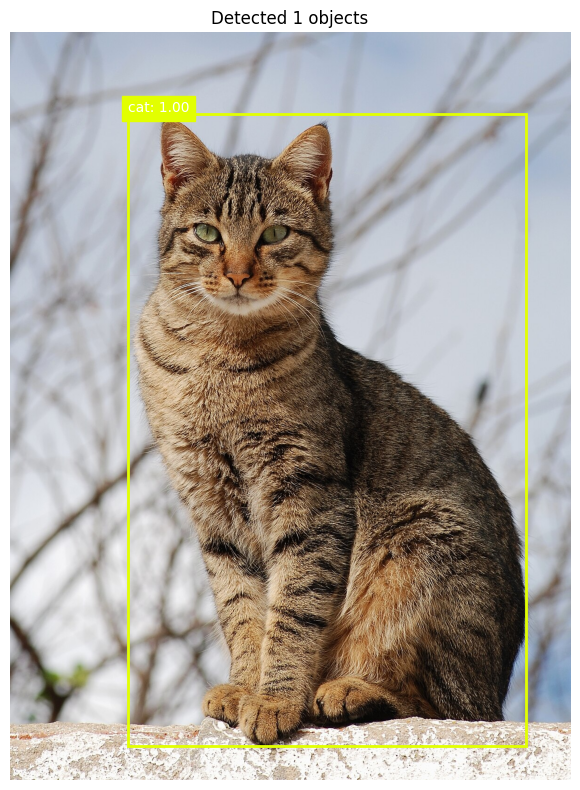

In [28]:
# Visualize detections
def visualize_detections(image, boxes, labels, scores, class_names):
    """Draw bounding boxes on image."""
    img_array = np.array(image).copy()
    
    colors = plt.cm.hsv(np.linspace(0, 1, len(class_names)))
    
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img_array)
    
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        color = colors[label % len(colors)][:3]
        
        # Draw rectangle
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                             fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)
        
        # Add label
        label_text = f"{class_names[label]}: {score:.2f}"
        ax.text(x1, y1-5, label_text, fontsize=10,
               color='white', backgroundcolor=color)
    
    ax.axis('off')
    plt.title(f'Detected {len(boxes)} objects')
    plt.tight_layout()
    plt.show()

visualize_detections(detection_image, boxes, labels, scores, coco_labels)

Predicted box: [100, 100, 200, 200]
Ground truth box: [110, 105, 210, 205]
IoU: 0.7467


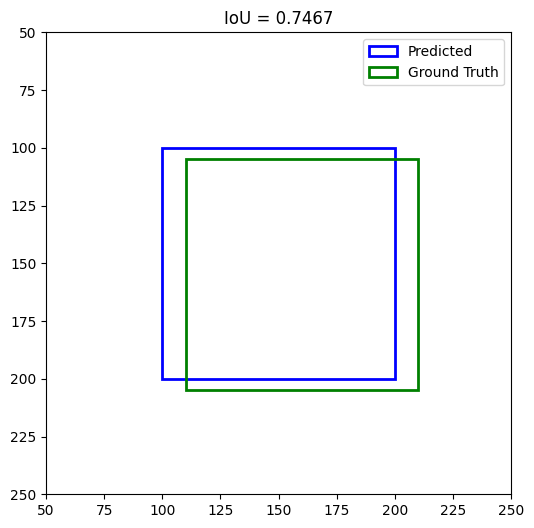

In [29]:
# Calculate IoU example
def calculate_iou(box1, box2):
    """Calculate Intersection over Union between two boxes."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    # Intersection area
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    
    # Union area
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

# Example IoU calculation
box_pred = [100, 100, 200, 200]
box_gt = [110, 105, 210, 205]

iou = calculate_iou(box_pred, box_gt)
print(f"Predicted box: {box_pred}")
print(f"Ground truth box: {box_gt}")
print(f"IoU: {iou:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(6, 6))
ax.add_patch(plt.Rectangle((box_pred[0], box_pred[1]), 
                           box_pred[2]-box_pred[0], box_pred[3]-box_pred[1],
                           fill=False, edgecolor='blue', linewidth=2, label='Predicted'))
ax.add_patch(plt.Rectangle((box_gt[0], box_gt[1]), 
                           box_gt[2]-box_gt[0], box_gt[3]-box_gt[1],
                           fill=False, edgecolor='green', linewidth=2, label='Ground Truth'))
ax.set_xlim(50, 250)
ax.set_ylim(250, 50)
ax.legend()
ax.set_title(f'IoU = {iou:.4f}')
plt.show()

## 7. Semantic Segmentation <a name="7-segmentation"></a>

Pixel-wise classification with segmentation models.

In [30]:
# Load a pretrained segmentation model (DeepLabV3)
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

seg_weights = DeepLabV3_ResNet50_Weights.DEFAULT
seg_model = deeplabv3_resnet50(weights=seg_weights).to(device)
seg_model.eval()

# Pascal VOC classes
voc_classes = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'cow', 'diningtable', 'dog', 'horse',
    'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
print(f"VOC classes: {voc_classes}")

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /Users/yenokhakobyan/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:05<00:00, 29.5MB/s] 

VOC classes: ['background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


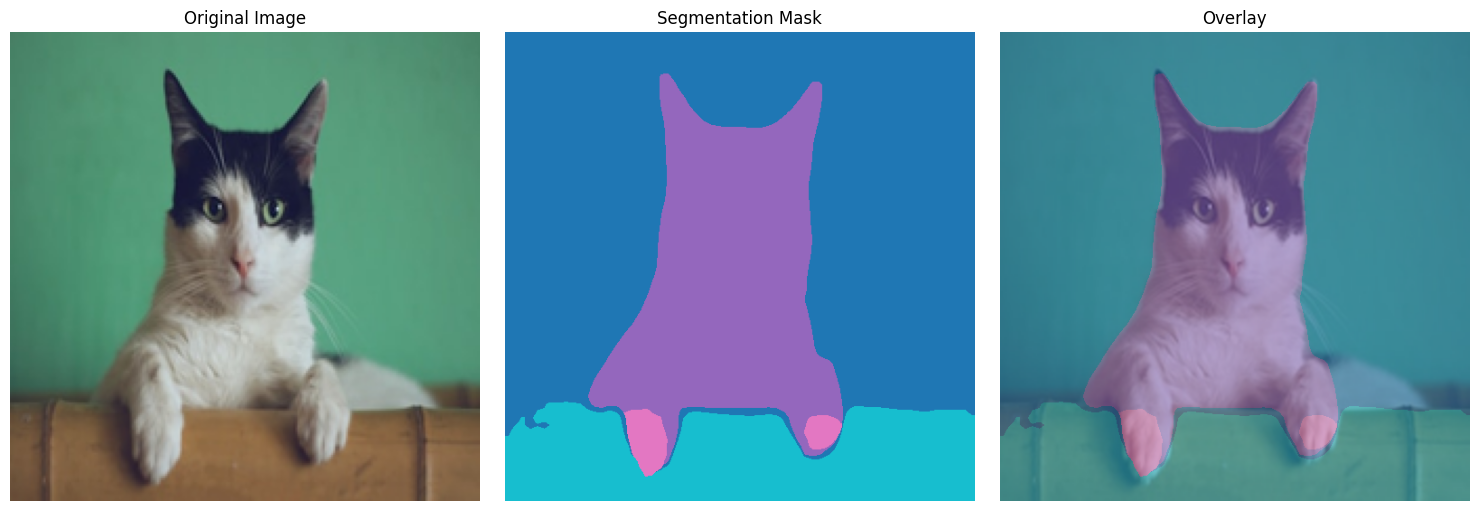


Detected classes: ['background', 'cat', 'horse', 'train']


In [31]:
def segment_image(model, image):
    """Run semantic segmentation on an image."""
    model.eval()
    
    # Preprocess
    preprocess = seg_weights.transforms()
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    
    # Run segmentation
    with torch.no_grad():
        output = model(input_tensor)['out']
    
    # Get class predictions
    predictions = output.argmax(1).squeeze().cpu().numpy()
    
    return predictions, output

# Run segmentation
seg_mask, seg_output = segment_image(seg_model, sample_image)

# Create colormap
def create_pascal_colormap():
    """Create colormap for Pascal VOC."""
    colormap = np.zeros((256, 3), dtype=np.uint8)
    for i in range(21):
        colormap[i] = [int(x * 255) for x in plt.cm.tab20(i)[:3]]
    return colormap

colormap = create_pascal_colormap()
seg_colored = colormap[seg_mask]

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sample_image)
axes[0].set_title('Original Image')

axes[1].imshow(seg_colored)
axes[1].set_title('Segmentation Mask')

# Overlay
img_array = np.array(sample_image.resize((seg_mask.shape[1], seg_mask.shape[0])))
overlay = img_array * 0.5 + seg_colored * 0.5
axes[2].imshow(overlay.astype(np.uint8))
axes[2].set_title('Overlay')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

# Print detected classes
unique_classes = np.unique(seg_mask)
print(f"\nDetected classes: {[voc_classes[c] for c in unique_classes]}")

In [32]:
# Calculate Dice coefficient
def dice_coefficient(pred, target, class_id):
    """Calculate Dice coefficient for a specific class."""
    pred_mask = (pred == class_id).astype(float)
    target_mask = (target == class_id).astype(float)
    
    intersection = np.sum(pred_mask * target_mask)
    union = np.sum(pred_mask) + np.sum(target_mask)
    
    if union == 0:
        return 1.0  # Both empty
    return 2.0 * intersection / union

# Example: Create a synthetic ground truth for demonstration
# In practice, you would have actual ground truth masks
print("Dice coefficient calculation example:")
print("Assuming the segmentation output is both prediction and ground truth (perfect match):")

for class_id in unique_classes:
    dice = dice_coefficient(seg_mask, seg_mask, class_id)
    class_pixels = np.sum(seg_mask == class_id)
    print(f"  {voc_classes[class_id]}: Dice = {dice:.4f} ({class_pixels} pixels)")

Dice coefficient calculation example:
Assuming the segmentation output is both prediction and ground truth (perfect match):
  background: Dice = 1.0000 (156603 pixels)
  cat: Dice = 1.0000 (65013 pixels)
  horse: Dice = 1.0000 (3760 pixels)
  train: Dice = 1.0000 (45024 pixels)


## 8. Vision Transformers <a name="8-vit"></a>

Using Vision Transformer models for classification.

In [33]:
# Load ViT model
from torchvision.models import vit_b_16, ViT_B_16_Weights

vit_weights = ViT_B_16_Weights.DEFAULT
vit_model = vit_b_16(weights=vit_weights).to(device)
vit_model.eval()

# Count parameters
vit_params = sum(p.numel() for p in vit_model.parameters())
print(f"ViT-B/16 parameters: {vit_params:,} ({vit_params/1e6:.1f}M)")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /Users/yenokhakobyan/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:10<00:00, 34.6MB/s] 


ViT-B/16 parameters: 86,567,656 (86.6M)


In [34]:
# Classify with ViT
vit_preprocess = vit_weights.transforms()

def classify_with_vit(model, image, top_k=5):
    """Classify using Vision Transformer."""
    model.eval()
    
    input_tensor = vit_preprocess(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)
    
    top_probs, top_indices = torch.topk(probabilities, top_k)
    
    results = []
    for prob, idx in zip(top_probs[0], top_indices[0]):
        results.append((imagenet_labels[idx], prob.item()))
    
    return results

# Compare ResNet vs ViT
print("Classification Comparison:")
print("\nResNet-50:")
resnet_results = classify_image(models.resnet50(weights='IMAGENET1K_V1').to(device), sample_image)
for label, prob in resnet_results[:3]:
    print(f"  {label}: {prob*100:.1f}%")

print("\nViT-B/16:")
vit_results = classify_with_vit(vit_model, sample_image)
for label, prob in vit_results[:3]:
    print(f"  {label}: {prob*100:.1f}%")

Classification Comparison:

ResNet-50:
  Egyptian cat: 78.5%
  tabby: 5.8%
  Siamese cat: 3.2%

ViT-B/16:
  Egyptian cat: 46.8%
  carton: 30.5%
  crate: 5.8%


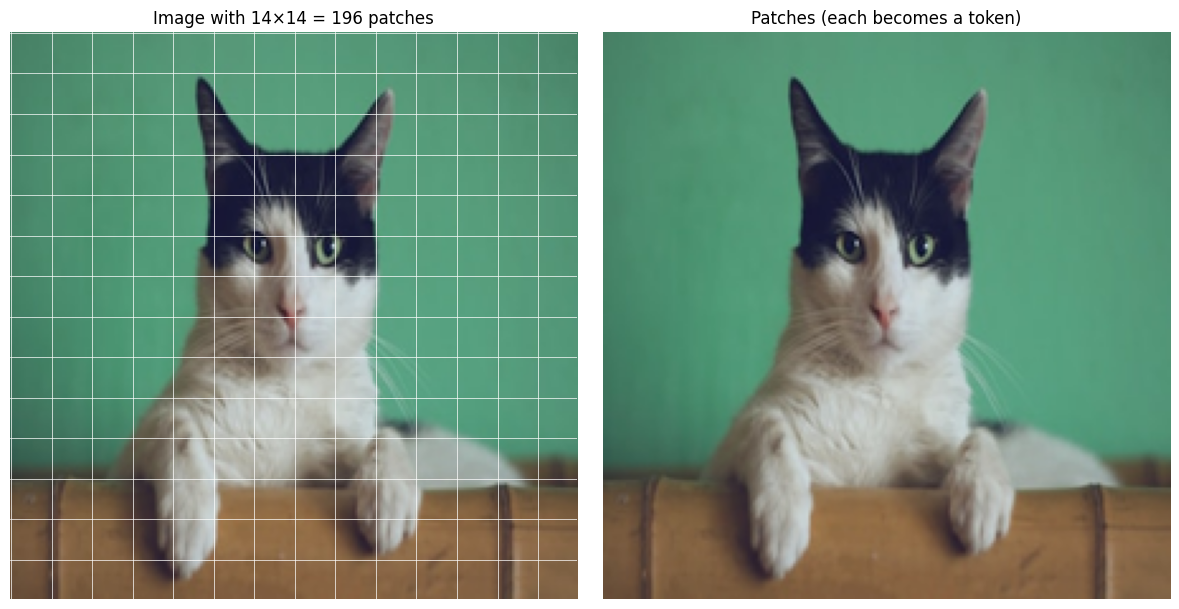


ViT-B/16 tokenization:
  Image size: 224×224
  Patch size: 16×16
  Number of patches: 14² = 196
  Each patch: 16×16×3 = 768 values
  Embedded to: 768 dimensions
  Total sequence: 196 + 1 (CLS token) = 197 tokens


In [35]:
# Visualize attention maps (simplified)
def visualize_vit_patches(image, patch_size=16):
    """Visualize how ViT splits image into patches."""
    img_array = np.array(image.resize((224, 224)))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Original image with grid
    axes[0].imshow(img_array)
    
    # Draw grid
    for i in range(0, 224, patch_size):
        axes[0].axhline(y=i, color='white', linewidth=0.5)
        axes[0].axvline(x=i, color='white', linewidth=0.5)
    
    n_patches = 224 // patch_size
    axes[0].set_title(f'Image with {n_patches}×{n_patches} = {n_patches**2} patches')
    axes[0].axis('off')
    
    # Show individual patches
    patch_grid = np.zeros((n_patches * patch_size, n_patches * patch_size, 3), dtype=np.uint8)
    
    for i in range(n_patches):
        for j in range(n_patches):
            patch = img_array[i*patch_size:(i+1)*patch_size, 
                             j*patch_size:(j+1)*patch_size]
            # Add border
            patch_with_border = np.pad(patch, ((1, 1), (1, 1), (0, 0)), 
                                       mode='constant', constant_values=255)
            patch_grid[i*patch_size:(i+1)*patch_size,
                      j*patch_size:(j+1)*patch_size] = patch
    
    axes[1].imshow(patch_grid)
    axes[1].set_title('Patches (each becomes a token)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nViT-B/16 tokenization:")
    print(f"  Image size: 224×224")
    print(f"  Patch size: {patch_size}×{patch_size}")
    print(f"  Number of patches: {n_patches}² = {n_patches**2}")
    print(f"  Each patch: {patch_size}×{patch_size}×3 = {patch_size*patch_size*3} values")
    print(f"  Embedded to: 768 dimensions")
    print(f"  Total sequence: {n_patches**2} + 1 (CLS token) = {n_patches**2 + 1} tokens")

visualize_vit_patches(sample_image)

## 9. CLIP Zero-Shot Classification <a name="9-clip"></a>

Using CLIP for zero-shot image classification.

In [36]:
# Install CLIP if needed
# !pip install git+https://github.com/openai/CLIP.git
# Or use transformers
# !pip install transformers

In [37]:
try:
    from transformers import CLIPProcessor, CLIPModel
    
    # Load CLIP model
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    
    print("CLIP model loaded successfully!")
    clip_available = True
except ImportError:
    print("CLIP not available. Install with: pip install transformers")
    clip_available = False

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


CLIP model loaded successfully!


CLIP Zero-Shot Classification:
Image: Cat photo

Predictions:
  cat: 97.8%
  person: 1.3%
  dog: 0.9%
  bird: 0.1%
  house: 0.0%
  car: 0.0%
  tree: 0.0%


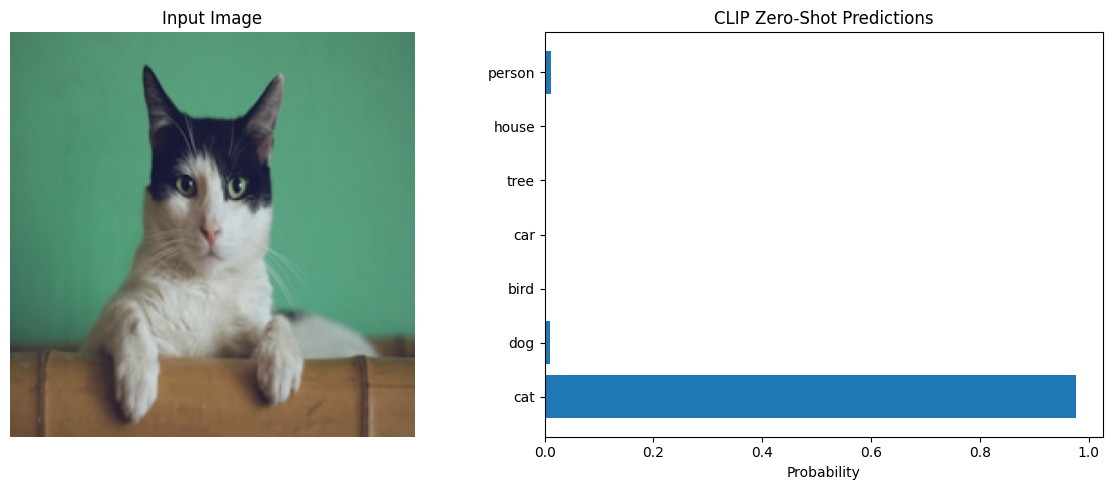

In [38]:
if clip_available:
    def clip_zero_shot(model, processor, image, text_labels):
        """Perform zero-shot classification with CLIP."""
        # Create text prompts
        text_prompts = [f"a photo of a {label}" for label in text_labels]
        
        # Process inputs
        inputs = processor(
            text=text_prompts,
            images=image,
            return_tensors="pt",
            padding=True
        ).to(device)
        
        # Get embeddings
        with torch.no_grad():
            outputs = model(**inputs)
            
        # Calculate similarity
        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=1)
        
        return probs[0].cpu().numpy()
    
    # Test with custom labels
    custom_labels = ["cat", "dog", "bird", "car", "tree", "house", "person"]
    
    probs = clip_zero_shot(clip_model, clip_processor, sample_image, custom_labels)
    
    print("CLIP Zero-Shot Classification:")
    print(f"Image: Cat photo")
    print(f"\nPredictions:")
    
    # Sort by probability
    sorted_indices = np.argsort(probs)[::-1]
    for idx in sorted_indices:
        print(f"  {custom_labels[idx]}: {probs[idx]*100:.1f}%")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].imshow(sample_image)
    axes[0].set_title('Input Image')
    axes[0].axis('off')
    
    axes[1].barh(custom_labels, probs)
    axes[1].set_xlabel('Probability')
    axes[1].set_title('CLIP Zero-Shot Predictions')
    
    plt.tight_layout()
    plt.show()

In [39]:
if clip_available:
    # Test with more specific labels
    specific_labels = [
        "tabby cat", "persian cat", "siamese cat",
        "orange cat", "black cat", "white cat",
        "dog", "rabbit"
    ]
    
    probs = clip_zero_shot(clip_model, clip_processor, sample_image, specific_labels)
    
    print("\nCLIP with specific cat breeds:")
    sorted_indices = np.argsort(probs)[::-1]
    for idx in sorted_indices[:5]:
        print(f"  {specific_labels[idx]}: {probs[idx]*100:.1f}%")


CLIP with specific cat breeds:
  white cat: 60.7%
  tabby cat: 24.2%
  siamese cat: 7.9%
  black cat: 2.5%
  orange cat: 1.9%


## 10. Diffusion Models <a name="10-diffusion"></a>

Understanding diffusion process with visualization.

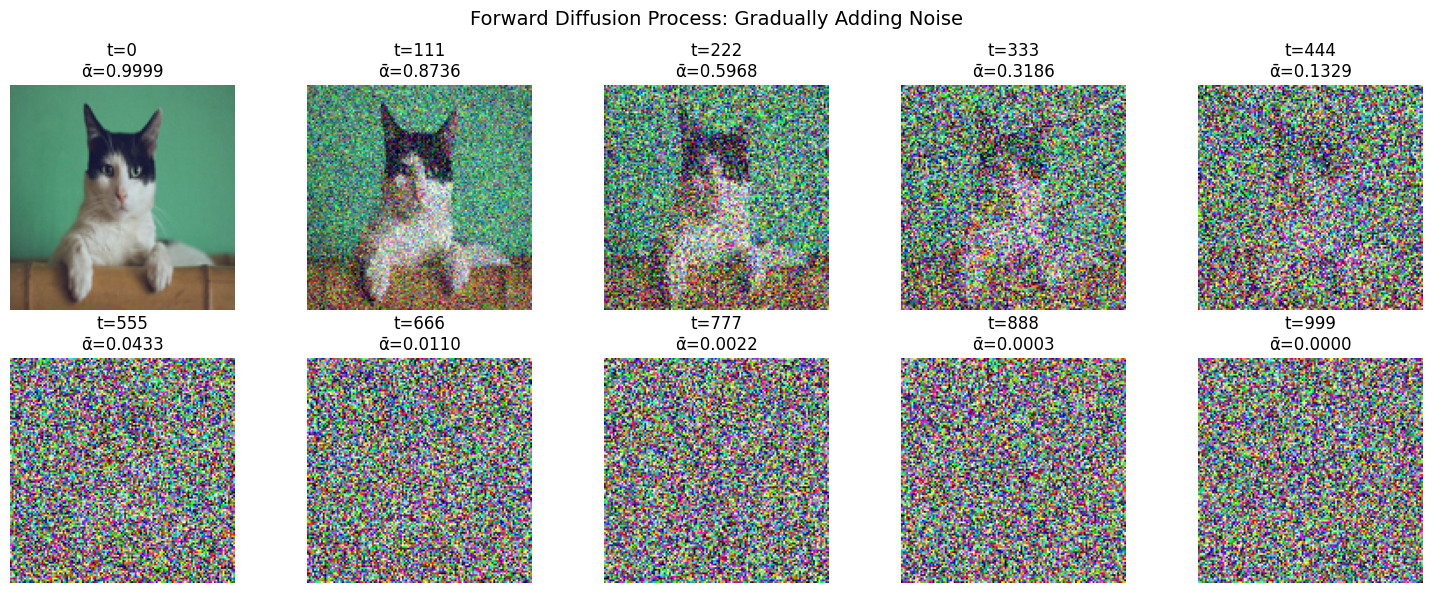


Noise schedule:
  β ranges from 0.0001 to 0.02
  At t=0: ᾱ = 0.9999 (almost original image)
  At t=500: ᾱ = 0.0778 (50% signal, 50% noise)
  At t=999: ᾱ = 0.000040 (almost pure noise)


In [40]:
# Demonstrate the forward diffusion process
def forward_diffusion_demo(image, num_steps=10):
    """Visualize the forward diffusion process (adding noise)."""
    # Convert to tensor and normalize to [-1, 1]
    img_tensor = transforms.ToTensor()(image.resize((128, 128)))
    img_tensor = img_tensor * 2 - 1  # [0,1] -> [-1,1]
    
    # Linear noise schedule
    beta_start = 0.0001
    beta_end = 0.02
    betas = np.linspace(beta_start, beta_end, 1000)
    alphas = 1 - betas
    alpha_bars = np.cumprod(alphas)
    
    # Select timesteps to visualize
    timesteps = np.linspace(0, 999, num_steps, dtype=int)
    
    fig, axes = plt.subplots(2, num_steps // 2, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, t in enumerate(timesteps):
        # Get alpha_bar for this timestep
        alpha_bar_t = alpha_bars[t]
        
        # Sample noise
        noise = torch.randn_like(img_tensor)
        
        # Add noise: x_t = sqrt(alpha_bar) * x_0 + sqrt(1-alpha_bar) * noise
        noisy_img = np.sqrt(alpha_bar_t) * img_tensor + np.sqrt(1 - alpha_bar_t) * noise
        
        # Convert back to displayable format
        display_img = (noisy_img + 1) / 2  # [-1,1] -> [0,1]
        display_img = display_img.clamp(0, 1)
        display_img = display_img.permute(1, 2, 0).numpy()
        
        axes[i].imshow(display_img)
        axes[i].set_title(f't={t}\nᾱ={alpha_bar_t:.4f}')
        axes[i].axis('off')
    
    plt.suptitle('Forward Diffusion Process: Gradually Adding Noise', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("\nNoise schedule:")
    print(f"  β ranges from {beta_start} to {beta_end}")
    print(f"  At t=0: ᾱ = {alpha_bars[0]:.4f} (almost original image)")
    print(f"  At t=500: ᾱ = {alpha_bars[500]:.4f} (50% signal, 50% noise)")
    print(f"  At t=999: ᾱ = {alpha_bars[999]:.6f} (almost pure noise)")

forward_diffusion_demo(sample_image)

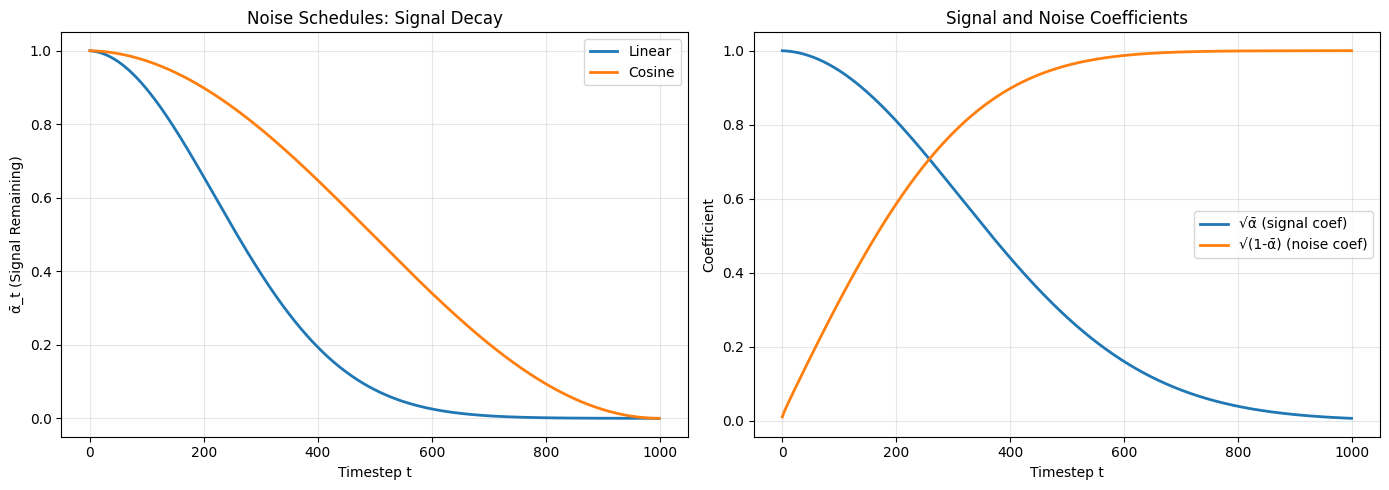

Diffusion formula: x_t = √ᾱ_t × x_0 + √(1-ᾱ_t) × ε

Key timesteps (linear schedule):
  t=0: signal=1.000, noise=0.010
  t=250: signal=0.722, noise=0.692
  t=500: signal=0.279, noise=0.960
  t=750: signal=0.057, noise=0.998
  t=999: signal=0.006, noise=1.000


In [41]:
# Visualize the noise schedule
def visualize_noise_schedule():
    """Visualize different noise schedules."""
    T = 1000
    t = np.arange(T)
    
    # Linear schedule
    beta_linear = np.linspace(0.0001, 0.02, T)
    alpha_bar_linear = np.cumprod(1 - beta_linear)
    
    # Cosine schedule
    s = 0.008
    f_t = np.cos((t/T + s) / (1 + s) * np.pi / 2) ** 2
    alpha_bar_cosine = f_t / f_t[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot alpha_bar
    axes[0].plot(t, alpha_bar_linear, label='Linear', linewidth=2)
    axes[0].plot(t, alpha_bar_cosine, label='Cosine', linewidth=2)
    axes[0].set_xlabel('Timestep t')
    axes[0].set_ylabel('ᾱ_t (Signal Remaining)')
    axes[0].set_title('Noise Schedules: Signal Decay')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot sqrt values (what multiplies signal and noise)
    axes[1].plot(t, np.sqrt(alpha_bar_linear), label='√ᾱ (signal coef)', linewidth=2)
    axes[1].plot(t, np.sqrt(1 - alpha_bar_linear), label='√(1-ᾱ) (noise coef)', linewidth=2)
    axes[1].set_xlabel('Timestep t')
    axes[1].set_ylabel('Coefficient')
    axes[1].set_title('Signal and Noise Coefficients')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("Diffusion formula: x_t = √ᾱ_t × x_0 + √(1-ᾱ_t) × ε")
    print("\nKey timesteps (linear schedule):")
    for t_val in [0, 250, 500, 750, 999]:
        print(f"  t={t_val}: signal={np.sqrt(alpha_bar_linear[t_val]):.3f}, "
              f"noise={np.sqrt(1-alpha_bar_linear[t_val]):.3f}")

visualize_noise_schedule()

## 11. Edge Deployment <a name="11-edge"></a>

Model efficiency, quantization, and comparison.

In [42]:
# Compare model efficiency
def model_efficiency_comparison():
    """Compare different models for edge deployment."""
    models_to_compare = {
        'ResNet-18': models.resnet18(weights='IMAGENET1K_V1'),
        'ResNet-50': models.resnet50(weights='IMAGENET1K_V1'),
        'MobileNetV2': models.mobilenet_v2(weights='IMAGENET1K_V1'),
        'MobileNetV3-Small': models.mobilenet_v3_small(weights='IMAGENET1K_V1'),
        'EfficientNet-B0': models.efficientnet_b0(weights='IMAGENET1K_V1'),
        'SqueezeNet': models.squeezenet1_1(weights='IMAGENET1K_V1'),
    }
    
    results = []
    
    for name, model in models_to_compare.items():
        model = model.to(device)
        model.eval()
        
        # Count parameters
        params = sum(p.numel() for p in model.parameters())
        
        # Measure inference time
        input_tensor = torch.randn(1, 3, 224, 224).to(device)
        
        # Warmup
        with torch.no_grad():
            for _ in range(10):
                _ = model(input_tensor)
        
        # Time inference
        import time
        times = []
        with torch.no_grad():
            for _ in range(50):
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                start = time.time()
                _ = model(input_tensor)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                times.append(time.time() - start)
        
        avg_time = np.mean(times) * 1000  # Convert to ms
        
        # Model size
        size_mb = params * 4 / (1024 * 1024)  # Assuming float32
        
        results.append({
            'Model': name,
            'Parameters (M)': params / 1e6,
            'Size (MB)': size_mb,
            'Latency (ms)': avg_time,
            'Throughput (img/s)': 1000 / avg_time
        })
    
    return results

efficiency_results = model_efficiency_comparison()

# Display results
print("Model Efficiency Comparison:")
print("-" * 80)
print(f"{'Model':<20} {'Params (M)':<12} {'Size (MB)':<12} {'Latency (ms)':<14} {'Throughput':<12}")
print("-" * 80)

for r in efficiency_results:
    print(f"{r['Model']:<20} {r['Parameters (M)']:<12.2f} {r['Size (MB)']:<12.1f} "
          f"{r['Latency (ms)']:<14.2f} {r['Throughput (img/s)']:<12.1f}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /Users/yenokhakobyan/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 15.0MB/s]


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /Users/yenokhakobyan/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 10.6MB/s]


Model Efficiency Comparison:
--------------------------------------------------------------------------------
Model                Params (M)   Size (MB)    Latency (ms)   Throughput  
--------------------------------------------------------------------------------
ResNet-18            11.69        44.6         10.89          91.9        
ResNet-50            25.56        97.5         25.50          39.2        
MobileNetV2          3.50         13.4         43.11          23.2        
MobileNetV3-Small    2.54         9.7          79.73          12.5        
EfficientNet-B0      5.29         20.2         230.31         4.3         
SqueezeNet           1.24         4.7          6.38           156.9       


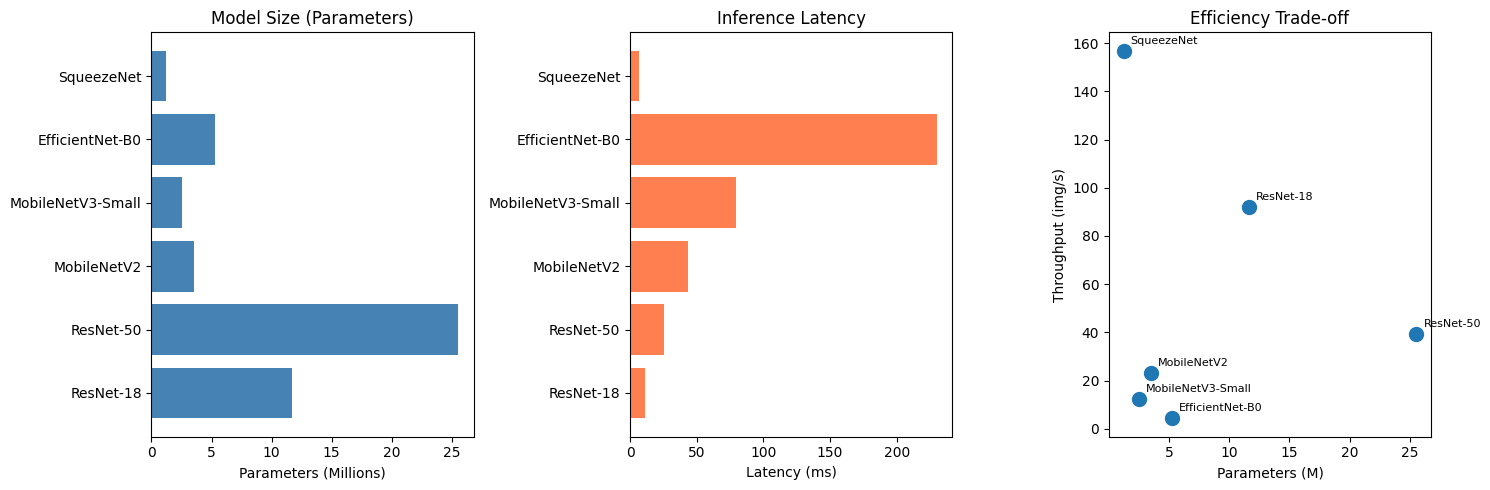

In [43]:
# Visualize the comparison
import pandas as pd

df = pd.DataFrame(efficiency_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Parameters
axes[0].barh(df['Model'], df['Parameters (M)'], color='steelblue')
axes[0].set_xlabel('Parameters (Millions)')
axes[0].set_title('Model Size (Parameters)')

# Latency
axes[1].barh(df['Model'], df['Latency (ms)'], color='coral')
axes[1].set_xlabel('Latency (ms)')
axes[1].set_title('Inference Latency')

# Size vs Throughput
axes[2].scatter(df['Parameters (M)'], df['Throughput (img/s)'], s=100)
for i, row in df.iterrows():
    axes[2].annotate(row['Model'], (row['Parameters (M)'], row['Throughput (img/s)']),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[2].set_xlabel('Parameters (M)')
axes[2].set_ylabel('Throughput (img/s)')
axes[2].set_title('Efficiency Trade-off')

plt.tight_layout()
plt.show()

In [44]:
# Demonstrate quantization
def quantization_demo():
    """Demonstrate model quantization."""
    # Load a model
    model_fp32 = models.mobilenet_v2(weights='IMAGENET1K_V1')
    model_fp32.eval()
    
    # Dynamic quantization (simplest form)
    model_int8 = torch.quantization.quantize_dynamic(
        model_fp32, 
        {nn.Linear},  # Quantize linear layers
        dtype=torch.qint8
    )
    
    # Compare sizes
    import tempfile
    import os
    
    with tempfile.TemporaryDirectory() as tmpdir:
        # Save FP32 model
        fp32_path = os.path.join(tmpdir, 'model_fp32.pth')
        torch.save(model_fp32.state_dict(), fp32_path)
        fp32_size = os.path.getsize(fp32_path) / (1024 * 1024)
        
        # Save INT8 model
        int8_path = os.path.join(tmpdir, 'model_int8.pth')
        torch.save(model_int8.state_dict(), int8_path)
        int8_size = os.path.getsize(int8_path) / (1024 * 1024)
    
    print("Quantization Results (MobileNetV2):")
    print(f"  FP32 model size: {fp32_size:.2f} MB")
    print(f"  INT8 model size: {int8_size:.2f} MB")
    print(f"  Size reduction: {(1 - int8_size/fp32_size)*100:.1f}%")
    
    # Test accuracy (both should give similar results)
    input_tensor = preprocess(sample_image).unsqueeze(0)
    
    with torch.no_grad():
        out_fp32 = model_fp32(input_tensor)
        out_int8 = model_int8(input_tensor)
    
    # Compare top predictions
    _, pred_fp32 = out_fp32.topk(5)
    _, pred_int8 = out_int8.topk(5)
    
    print(f"\nTop-5 predictions match: {torch.equal(pred_fp32, pred_int8)}")
    
    # Show predictions
    print("\nFP32 predictions:")
    probs_fp32 = F.softmax(out_fp32, dim=1)[0]
    for idx in pred_fp32[0][:3]:
        print(f"  {imagenet_labels[idx]}: {probs_fp32[idx]*100:.1f}%")
    
    print("\nINT8 predictions:")
    probs_int8 = F.softmax(out_int8, dim=1)[0]
    for idx in pred_int8[0][:3]:
        print(f"  {imagenet_labels[idx]}: {probs_int8[idx]*100:.1f}%")

quantization_demo()

RuntimeError: Didn't find engine for operation quantized::linear_prepack NoQEngine

In [ ]:
# Demonstrate depthwise separable convolution
def depthwise_separable_demo():
    """Compare standard conv vs depthwise separable conv."""
    in_channels = 64
    out_channels = 128
    kernel_size = 3
    
    # Standard convolution
    standard_conv = nn.Conv2d(in_channels, out_channels, kernel_size, padding=1)
    
    # Depthwise separable convolution
    depthwise_conv = nn.Conv2d(in_channels, in_channels, kernel_size, 
                               padding=1, groups=in_channels)  # groups=in_channels makes it depthwise
    pointwise_conv = nn.Conv2d(in_channels, out_channels, 1)  # 1x1 conv
    
    # Count parameters
    standard_params = sum(p.numel() for p in standard_conv.parameters())
    depthwise_params = sum(p.numel() for p in depthwise_conv.parameters())
    pointwise_params = sum(p.numel() for p in pointwise_conv.parameters())
    separable_params = depthwise_params + pointwise_params
    
    print("Depthwise Separable Convolution:")
    print(f"  Input: {in_channels} channels")
    print(f"  Output: {out_channels} channels")
    print(f"  Kernel size: {kernel_size}x{kernel_size}")
    print(f"\nStandard Conv parameters:")
    print(f"  Weight: {kernel_size}×{kernel_size}×{in_channels}×{out_channels} = {kernel_size*kernel_size*in_channels*out_channels}")
    print(f"  Bias: {out_channels}")
    print(f"  Total: {standard_params}")
    print(f"\nDepthwise Separable Conv parameters:")
    print(f"  Depthwise: {kernel_size}×{kernel_size}×{in_channels} + {in_channels} = {depthwise_params}")
    print(f"  Pointwise: 1×1×{in_channels}×{out_channels} + {out_channels} = {pointwise_params}")
    print(f"  Total: {separable_params}")
    print(f"\nParameter reduction: {(1 - separable_params/standard_params)*100:.1f}%")
    print(f"Ratio: 1/{standard_params/separable_params:.1f}")
    
    # Verify output shapes are the same
    x = torch.randn(1, in_channels, 14, 14)
    out_standard = standard_conv(x)
    out_separable = pointwise_conv(depthwise_conv(x))
    
    print(f"\nOutput shapes:")
    print(f"  Standard: {out_standard.shape}")
    print(f"  Separable: {out_separable.shape}")

depthwise_separable_demo()

## Summary

This notebook demonstrated:

1. **Image Representation**: How images are stored as tensors, color spaces, and normalization
2. **Convolution**: Manual convolution, different kernels, padding/stride/dilation
3. **Classical CV**: Edge detection (Sobel, Canny), corner detection (Harris), feature descriptors (SIFT)
4. **CNN Architectures**: ResNet, VGG, MobileNet, EfficientNet comparisons
5. **Object Detection**: Faster R-CNN, bounding boxes, IoU calculation
6. **Segmentation**: DeepLabV3, pixel-wise classification, Dice coefficient
7. **Vision Transformers**: ViT patch tokenization and classification
8. **CLIP**: Zero-shot classification with custom labels
9. **Diffusion Models**: Forward process visualization and noise schedules
10. **Edge Deployment**: Model comparison, quantization, depthwise separable convolution

Each section includes working code with real images that you can modify and experiment with!